<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Simulation Based Inference: Exercises

In [1]:
# Colab setup — install packages not preinstalled on Colab.
!pip install emcee pytorch_lightning getdist nflows sbi --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.0/836.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 15.0 MB/s eta 0:00:00


In [2]:
# --- Compatibility patch for GetDist + NumPy 2.0 ---
# NumPy 2.0 removed np.infty, but older versions of GetDist still use it.
# This patch restores it at runtime before importing GetDist.

import numpy as np
if not hasattr(np, 'infty'):
    np.infty = np.inf  # Restore deprecated alias for compatibility

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import emcee
from scipy.stats import poisson
from scipy.stats import chi2
from scipy.optimize import basinhopping
from tqdm import tqdm
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from scipy.stats import norm
from getdist import plots, MCSamples
from scipy.integrate import quad
import multiprocessing
from multiprocessing import Pool
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
from sbi.inference import SNPE  # old name used in v0.22.0
from sbi.utils.torchutils import BoxUniform

In [4]:
%matplotlib inline

## Introduction

In the main notebook, our mock observations were generated by simply <span style="color:darkorange">adding some Gaussian noise to the theoretical data</span>. However, in a <span style="color:darkorange">real experiment</span>, our observations may be affected various <span style="color:darkorange">other effects</span>, which may be caused by the instruments, the environment, physical processes, etc. These effects are often very **hard to model with a simple analytical function**, and may introduce additional **biases** in the data.

In this exercise, we will assume that our observations are contaminated by two new effects: random instrumental drift and intermittent calibration errors.

1. **Random instrumental drift**: The instrument that we use to measure the data is not perfect, and its <span style="color:darkorange">calibration may drift over time</span> due to environmental factors or aging hardware. This drift will accumulate over time and so the measurements that we take at different times may be affected by a random offset. We can model this effect by adding a cumulative sum of normally distributed random values to the true magnitudes.
    <details>
    <summary>Why? [Click to expand]
     <br><br>
    </summary>
    This simulates the effect of a drift that changes the measurements in a continuous but random manner. The random values are drawn from a normal distribution with a mean of zero, ensuring that the drift can go in either direction (positive or negative) and has a variance that reflects the magnitude of the drift per observation.
    <br> <br>
    </details>


2. **Intermittent calibration errors**: The instrument may also suffer from occasional <span style="color:darkorange">large calibration errors</span> that occur at random intervals. This may be caused by a variety of factors, such as power surges, cosmic rays, mechanical disturbances, miscalibrations during the data collection process etc. We model these errors by introducing occasional large spikes in the observed magnitudes.

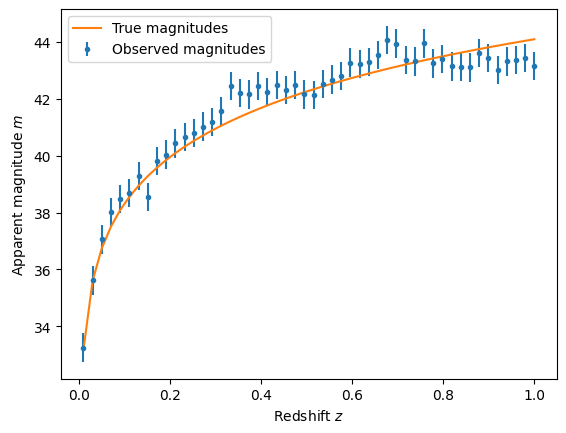

In [5]:
#random seed
np.random.seed(1235)
torch.manual_seed(1234)

# Constants
c = 299792.458  # Speed of light in km/s

# True cosmological parameters
true_Omega_m = 0.3
true_H0 = 70.0  # Hubble constant in km/s/Mpc

# Redshifts of the supernovae
z = np.linspace(0.01, 1.0, 50)

# Noise level in the observed magnitudes
sigma = 0.1

# Luminosity distance function
def luminosity_distance(z, Omega_m, H0):
    """ Calculate the luminosity distance for a given redshift, Omega_m and H0 """
    integrand = lambda z_prime: 1.0 / np.sqrt(Omega_m * (1 + z_prime)**3 + (1 - Omega_m))
    d_L = np.array([quad(integrand, 0, z_i)[0] for z_i in z])
    return (c * (1 + z) * d_L) / H0

# Generate synthetic data
# Generate synthetic data with non-linear transformation
d_L_true = luminosity_distance(z, true_Omega_m, true_H0)
m_true = 5 * np.log10(d_L_true) + 25

# Introduce random walk drift
def random_walk_drift(m, z):
    drift = np.cumsum(np.random.normal(0, 0.2, len(m)))
    return m + drift

# Introduce intermittent calibration errors
def intermittent_calibration_errors(m, z):
    errors = np.zeros_like(m)
    error_indices = np.random.choice(len(m), size=int(len(m) * 0.1), replace=False)
    errors[error_indices] = np.random.normal(0, 1, len(error_indices))
    return m + errors

# Apply both effects to the observed magnitudes
m_obs_drift = random_walk_drift(m_true, z)
m_obs = intermittent_calibration_errors(m_obs_drift, z) + np.random.normal(0, sigma, len(m_true))


# Plot synthetic data
plt.errorbar(z, m_obs, yerr=0.5, fmt='.', label='Observed magnitudes')
plt.plot(z, m_true, label='True magnitudes')
plt.xlabel('Redshift $z$')
plt.ylabel('Apparent magnitude $m$')
plt.legend()
plt.show()


## Part 1: Solving with Gaussian likelihood

**Problem:** Given the observed magnitudes $m_{\text{obs}}$ and redshifts $z$, infer the cosmological parameters $\Omega_m$ and $H_0$ using the traditional Bayesian approach assuming a Gaussian likelihood:

$$
\mathcal{L}(\Omega_m, H_0) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma_i^2}} \exp\left(-\frac{(m_{\text{obs},i} - m_{\text{th},i})^2}{2\sigma_i^2}\right), \tag{3}
$$

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Tasks:**

1. Define the prior, a Gaussian likelihood with some $\sigma$ and the posterior.
2. Run MCMC to sample from the posterior.
3. Plot the corner plot of the posterior samples and see if the results are consistent with the true values.

*(Worked solutions are in the **Solutions** section at the end of this notebook.)*

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>Click for tip</summary></b>

Do ***exactly*** what was done in the main notebook:

- For the prior, use a flat prior over $\Omega_m$ and $H_0$.
- For the Gaussian likelihood, you can assume a $\sigma$ looking at the data (I would assume $\sigma=0.5$, as in the main notebook).
- For MCMC, you can use the `emcee` package.

</details>
</div>

Task 1:

In [6]:
# Log-prior function
def log_prior(params):
    Omega_m, H0 = params
    if 0 < Omega_m < 1 and 50 < H0 < 100:
        return 0
    else:
        return -np.inf

# Define the log-likelihood function
def log_like(params, z, m_obs):
    Omega_m, H0 = params
    d_L = luminosity_distance(z, Omega_m, H0)
    m_th = 5 * np.log10(d_L) + 25  # Theoretical magnitudes
    sigma_m = 0.5  # Assumed standard deviation of magnitudes
    return -0.5 * np.sum(((m_obs - m_th) / sigma_m)**2)

# Log-posterior function
def log_post(params, z, m_obs):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf # If prior is -inf, return directly -inf
    else:
        return lp + log_like(params, z, m_obs)

Task 2:

In [7]:
# Sampling with `emcee`
ndim, nwalkers = 2, 16
ncpus = multiprocessing.cpu_count()

# Initialize walkers around a random position withing the prior volume
pos = np.random.uniform([0, 50], [1, 100], (nwalkers, ndim))

with Pool(ncpus) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_post, args=(z, m_obs), pool=pool)
    sampler.run_mcmc(pos, 3000, progress=True)

100%|██████████| 3000/3000 [01:59<00:00, 25.18it/s]


Task 3:

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_3940/2845518695.py:5: SyntaxWarning: invalid escape sequence '\O'
  samples = MCSamples(samples=flat_samples, names=['\Omega_m', 'H_0'], labels=['\Omega_m', 'H_0'])
/tmp/ipykernel_3940/2845518695.py:5: SyntaxWarning: invalid escape sequence '\O'
  samples = MCSamples(samples=flat_samples, names=['\Omega_m', 'H_0'], labels=['\Omega_m', 'H_0'])
/tmp/ipykernel_3940/2845518695.py:7: SyntaxWarning: invalid escape sequence '\O'
  g.triangle_plot(samples, filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0})


Removed no burn in


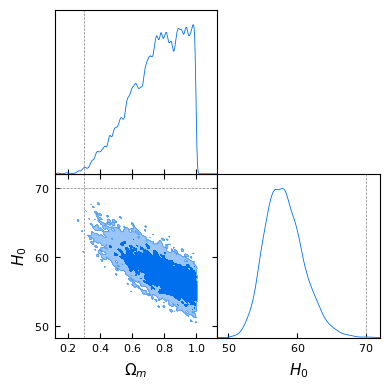

In [8]:
# Get samples and convert to GetDist MCSamples
flat_samples = sampler.get_chain(discard=1000, flat=True)

# GetDist plotting
samples = MCSamples(samples=flat_samples, names=['\Omega_m', 'H_0'], labels=['\Omega_m', 'H_0'])
g = plots.get_subplot_plotter(width_inch=4)
g.triangle_plot(samples, filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0})
plt.show()

## Part 2: Solving with Neural Posterior Estimation

**Problem:** Given the observed magnitudes $m_{\text{obs}}$ and redshifts $z$, infer the cosmological parameters $\Omega_m$ and $H_0$ using the Neural Posterior Estimation approach.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Tasks:**

1. Construct a **simulator** that generates the observed magnitudes $m_{\text{obs}}$ given the cosmological parameters $\Omega_m$ and $H_0$. Encode the random instrumental drifts and intermittent calibration errors in the simulator.
2. Generate a **training dataset** of observed magnitudes $m_{\text{obs}}$ and corresponding cosmological parameters $\Omega_m$ and $H_0$, by running the simulator for a range of randomly drawn parameters $\Omega_m$ and $H_0$.
3. Define the **Neural Posterior Estimator** class using the `sbi` package that will estimate the posterior with a normalizing flow.
4. Sample from the NPE, conditioning on the observed magnitudes $m_{\text{obs}}$ that we had in the beginning.
5. Plot the corner plot of the posterior samples and see if the results are consistent with the true values.

*(Worked solutions are in the **Solutions** section at the end of this notebook.)*

</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>Click for tip</summary></b>

Again, do ***exactly*** what was done in the main notebook. The actual changes that you need to implement are:
* In the simulator, introduce the random instrumental drifts and intermittent calibration errors.
* For the test data, use instead the observed magnitudes $m_{\text{obs}}$ that we showed in the beginning.

</details>
</div>

Task 1:

In [ ]:
# Forward model to simulate observed magnitudes (solution)
def luminosity_distance_simulator(params, z):
    Omega_m, H0 = params
    d_L = luminosity_distance(z, Omega_m, H0)
    m_th = 5 * np.log10(d_L) + 25
    m_sim_drift = random_walk_drift(m_th, z)
    m_sim = intermittent_calibration_errors(m_sim_drift, z) + np.random.normal(0, sigma, len(m_th))

    return m_sim

In [7]:
# Forward model to simulate observed magnitudes
def luminosity_distance_simulator(params, z):
    Omega_m, H0 = params
    d_L = luminosity_distance(z, Omega_m, H0)
    m_th = 5 * np.log10(d_L) + 25  # Theoretical magnitudes
    m_drift = random_walk_drift(m_th, z)  # add the random walk drift here
    m_drift_calibration = intermittent_calibration_errors(m_drift, z) # add the intermittent calibration errors here
    m_sim = np.random.normal(0, sigma, len(m_true)) # add the standard noise here, to get the final simulated magnitudes

    return (m_drift_calibration + m_sim)

Task 2:

In [10]:
np.random.seed(1234) # use random seed for reproducibility

# Generate training data
n_train = 20_000
param_samples = np.random.uniform(low=[0, 50], high=[1, 100], size=(n_train, 2)) # Parameter proposal
x_samples = np.array([luminosity_distance_simulator(theta, z) for theta in tqdm(param_samples)])

# Convert to tensors
param_samples = torch.tensor(param_samples, dtype=torch.float32)
x_samples = torch.tensor(x_samples, dtype=torch.float32)

100%|██████████| 20000/20000 [00:42<00:00, 474.53it/s]


Task 3:

In [11]:
prior = BoxUniform(low=torch.tensor([0.0, 50.0]), high=torch.tensor([1.0, 100.0]))
# Define the SBI model and give it the prior
inference = SNPE(prior=prior)
# append the parameter-simulation pairs
inference.append_simulations(param_samples, x_samples)
# train() the density estimator
density_estimator = inference.train()

# build posterior using the trained density estimator
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 68 epochs.

Tasks 4 & 5:

<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_5691/1205590315.py:11: SyntaxWarning: invalid escape sequence '\O'
  gd_samples_npe = MCSamples(samples=samples_npe, labels=['\Omega_m', 'H_0'], names=['\Omega_m', 'H_0'])
/tmp/ipykernel_5691/1205590315.py:11: SyntaxWarning: invalid escape sequence '\O'
  gd_samples_npe = MCSamples(samples=samples_npe, labels=['\Omega_m', 'H_0'], names=['\Omega_m', 'H_0'])
/tmp/ipykernel_5691/1205590315.py:15: SyntaxWarning: invalid escape sequence '\O'
  g.triangle_plot([gd_samples_npe], filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0}, legend_labels=['NPE', 'MCMC'])


  0%|          | 0/10000 [00:00<?, ?it/s]

Removed no burn in


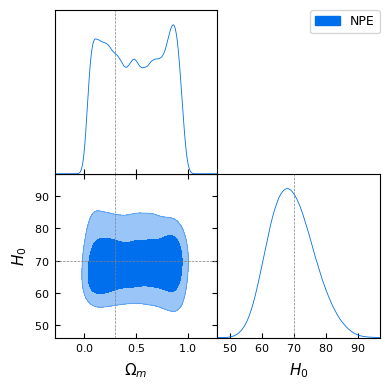

In [15]:
samples_npe = posterior.sample((10000,), x=m_obs)

# Convert to numpy (ensure on CPU and detached from graph)
if isinstance(samples_npe, torch.Tensor):
    samples_npe = samples_npe.detach().cpu().numpy()
else:
    samples_npe = np.asarray(samples_npe)


# Create a getdist MCSamples object
gd_samples_npe = MCSamples(samples=samples_npe, labels=['\Omega_m', 'H_0'], names=['\Omega_m', 'H_0'])

# Make a triangle/contour plot with getdist
g = plots.get_subplot_plotter()
g.triangle_plot([gd_samples_npe], filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0}, legend_labels=['NPE', 'MCMC'])

<hr style="border: none; border-top: 4px solid #888; margin: 2.5em 0 1em 0;">

# 🔑 Solutions

> **End of the exercise — solutions below.** Try the exercises yourself first, then check your work here. (These cells only need the imports and the data-generation cell from the top of the notebook.)

## Part 1, Task 1 — Prior, likelihood, and posterior

In [16]:
# Log-prior function
def log_prior(params):
    Omega_m, H0 = params
    if 0 < Omega_m < 1 and 50 < H0 < 100:
        return 0
    else:
        return -np.inf

# Define the log-likelihood function
def log_like(params, z, m_obs):
    Omega_m, H0 = params
    d_L = luminosity_distance(z, Omega_m, H0)
    m_th = 5 * np.log10(d_L) + 25
    sigma_m = 0.5  # Assumed standard deviation of magnitudes
    return -0.5 * np.sum(((m_obs - m_th) / sigma_m)**2)

# Log-posterior function
def log_post(params, z, m_obs):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    else:
        return lp + log_like(params, z, m_obs)

## Part 1, Task 2 — MCMC sampling

In [17]:
# Sampling with `emcee`
ndim, nwalkers = 2, 16
ncpus = multiprocessing.cpu_count()

# Initialize walkers around a random position withing the prior volume
pos = np.random.uniform([0, 50], [1, 100], (nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_post, args=(z, m_obs))
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████| 2000/2000 [00:58<00:00, 34.41it/s]


State([[ 0.94180139 56.13401311]
 [ 0.86577001 56.61053666]
 [ 0.52661226 61.61466221]
 [ 0.63941054 59.82116421]
 [ 0.8226821  56.48779431]
 [ 0.54158044 59.92543427]
 [ 0.48711661 60.84456702]
 [ 0.51436955 57.85592832]
 [ 0.61612286 60.10152842]
 [ 0.99016145 52.04495566]
 [ 0.71743188 54.8403836 ]
 [ 0.59706064 63.08423114]
 [ 0.95930376 55.74997715]
 [ 0.97412978 55.04167392]
 [ 0.57073766 58.15358566]
 [ 0.74604123 59.54168511]], log_prob=[-20.41593525 -20.41703208 -21.42074942 -20.87798967 -20.50399016
 -21.42384142 -21.75802694 -23.06386595 -20.96112393 -22.05642459
 -22.47463109 -22.17451958 -20.39856818 -20.41331243 -21.85091917
 -20.88778283], blobs=None, random_state=('MT19937', array([1352544669,  859851203, 2010629658, 1949112389, 3111665941,
       2022410549, 1556030311, 2285153333, 2657459776, 3906077433,
       1715641488, 1251667646, 2896559527, 1455318716,  280669285,
        720721648, 3716341455,  850926356, 2570176897, 1316562313,
       3012828310,  164363151, 1

## Part 1, Task 3 — Corner plot

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_5691/2845518695.py:5: SyntaxWarning: invalid escape sequence '\O'
  samples = MCSamples(samples=flat_samples, names=['\Omega_m', 'H_0'], labels=['\Omega_m', 'H_0'])
/tmp/ipykernel_5691/2845518695.py:5: SyntaxWarning: invalid escape sequence '\O'
  samples = MCSamples(samples=flat_samples, names=['\Omega_m', 'H_0'], labels=['\Omega_m', 'H_0'])
/tmp/ipykernel_5691/2845518695.py:7: SyntaxWarning: invalid escape sequence '\O'
  g.triangle_plot(samples, filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0})


Removed no burn in


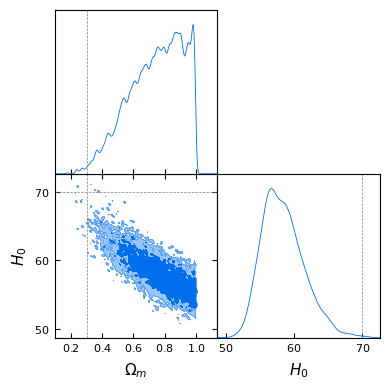

In [18]:
# Get samples and convert to GetDist MCSamples
flat_samples = sampler.get_chain(discard=1000, flat=True)

# GetDist plotting
samples = MCSamples(samples=flat_samples, names=['\Omega_m', 'H_0'], labels=['\Omega_m', 'H_0'])
g = plots.get_subplot_plotter(width_inch=4)
g.triangle_plot(samples, filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0})
plt.show()

## Part 2, Task 1 — The simulator

In [19]:
# Forward model to simulate observed magnitudes
def luminosity_distance_simulator(params, z):
    Omega_m, H0 = params
    d_L = luminosity_distance(z, Omega_m, H0)
    m_th = 5 * np.log10(d_L) + 25
    m_sim_drift = random_walk_drift(m_th, z)
    m_sim = intermittent_calibration_errors(m_sim_drift, z) + np.random.normal(0, sigma, len(m_th))

    return m_sim

## Part 2, Task 2 — Training data

In [20]:
np.random.seed(1234) # use random seed for reproducibility

# Generate training data
n_train = 20_000
param_samples = np.random.uniform(low=[0, 50], high=[1, 100], size=(n_train, 2)) # Parameter proposal
x_samples = np.array([luminosity_distance_simulator(theta, z) for theta in tqdm(param_samples)])

# Convert to tensors
param_samples = torch.tensor(param_samples, dtype=torch.float32)
x_samples = torch.tensor(x_samples, dtype=torch.float32)

100%|██████████| 20000/20000 [00:39<00:00, 503.13it/s]


## Part 2, Task 3 — NPE class

In [21]:
# Define the prior, and the SBI model and give it parameters theta and corresponding simulations x
prior = BoxUniform(low=torch.tensor([0.0, 50.0]), high=torch.tensor([1.0, 100.0]))

inference = SNPE(prior=prior)

inference.append_simulations(param_samples, x_samples)

density_estimator = inference.train()

posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 79 epochs.

## Part 2, Tasks 4 & 5 — Sample and plot

<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_5691/3955652026.py:11: SyntaxWarning: invalid escape sequence '\O'
  gd_samples_npe = MCSamples(samples=samples_npe, labels=['\Omega_m', 'H_0'], names=['\Omega_m', 'H_0'])
/tmp/ipykernel_5691/3955652026.py:11: SyntaxWarning: invalid escape sequence '\O'
  gd_samples_npe = MCSamples(samples=samples_npe, labels=['\Omega_m', 'H_0'], names=['\Omega_m', 'H_0'])
/tmp/ipykernel_5691/3955652026.py:15: SyntaxWarning: invalid escape sequence '\O'
  g.triangle_plot([gd_samples_npe, samples], filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0}, legend_labels=['NPE', 'MCMC'])


  0%|          | 0/10000 [00:00<?, ?it/s]

Removed no burn in


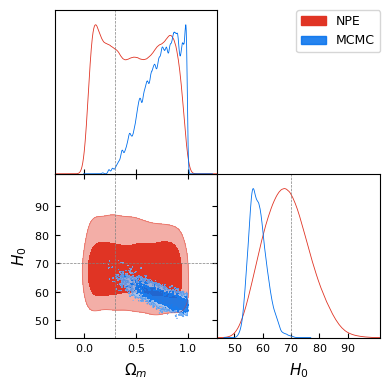

In [22]:
samples_npe = posterior.sample((10000,), x=m_obs)

# Convert to numpy (ensure on CPU and detached from graph)
if isinstance(samples_npe, torch.Tensor):
    samples_npe = samples_npe.detach().cpu().numpy()
else:
    samples_npe = np.asarray(samples_npe)


# Create a getdist MCSamples object
gd_samples_npe = MCSamples(samples=samples_npe, labels=['\Omega_m', 'H_0'], names=['\Omega_m', 'H_0'])

# Make a triangle/contour plot with getdist
g = plots.get_subplot_plotter()
g.triangle_plot([gd_samples_npe, samples], filled=True, markers={'\Omega_m': true_Omega_m, 'H_0': true_H0}, legend_labels=['NPE', 'MCMC'])